# Iris Flower Classification
### CodeAlpha Data Science Internship — Task 1

**Objective:** Use measurements of Iris flowers (sepal length/width, petal
length/width) to train a machine learning model that classifies each flower
into one of three species — *Iris-setosa*, *Iris-versicolor*, or
*Iris-virginica* — and evaluate the model's accuracy and performance.

**Dataset:** `Iris.csv` — 150 samples, 50 per species, 4 numeric measurement
features plus an `Id` column and the `Species` label.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

%matplotlib inline


## 2. Load the Data

In [2]:
df = pd.read_csv("data/Iris.csv")
print("Shape:", df.shape)
df.head()


Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.isnull().sum()


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## 3. Data Cleaning

- `Id` is just a row index and is dropped — it carries no predictive information.
- No missing values or duplicates need handling; the dataset is already clean and balanced (50 samples per species).


In [5]:
df_model = df.drop(columns=['Id']) if 'Id' in df.columns else df.copy()
print("Duplicate rows:", df_model.duplicated().sum())
df_model = df_model.drop_duplicates()
print("Shape after cleaning:", df_model.shape)
df_model['Species'].value_counts()


Duplicate rows: 3
Shape after cleaning: (147, 5)


Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

## 4. Exploratory Data Analysis

In [6]:
df_model.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


/tmp/ipykernel_534/1852342006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='Species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_534/1852342006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='Species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_534/1852342006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='Species', y=feat, ax=ax, palette='Set2')
/tmp/ipykernel_534/1852342006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

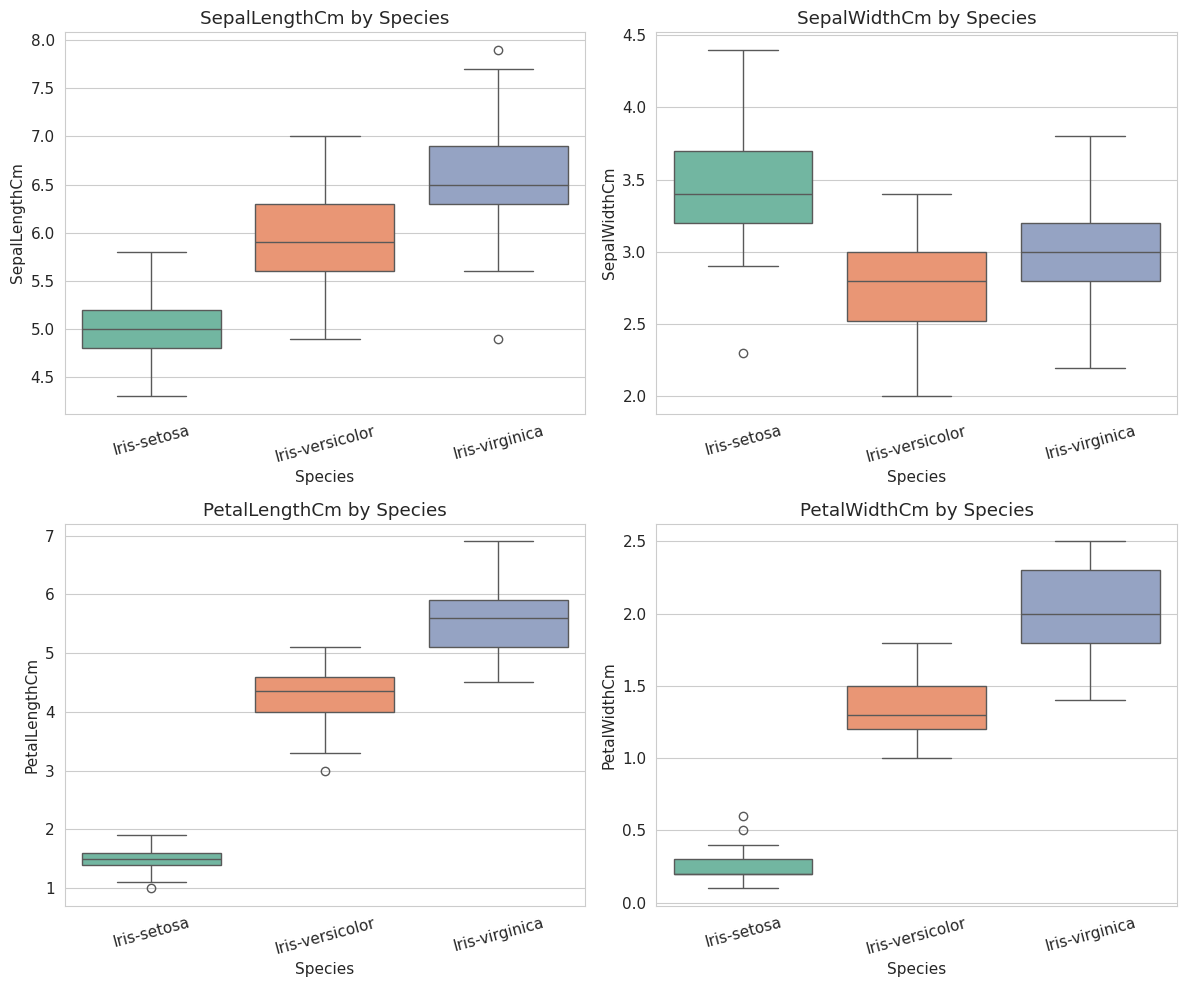

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df_model, x='Species', y=feat, ax=ax, palette='Set2')
    ax.set_title(f'{feat} by Species')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('images/01_feature_boxplots.png', dpi=150)
plt.show()


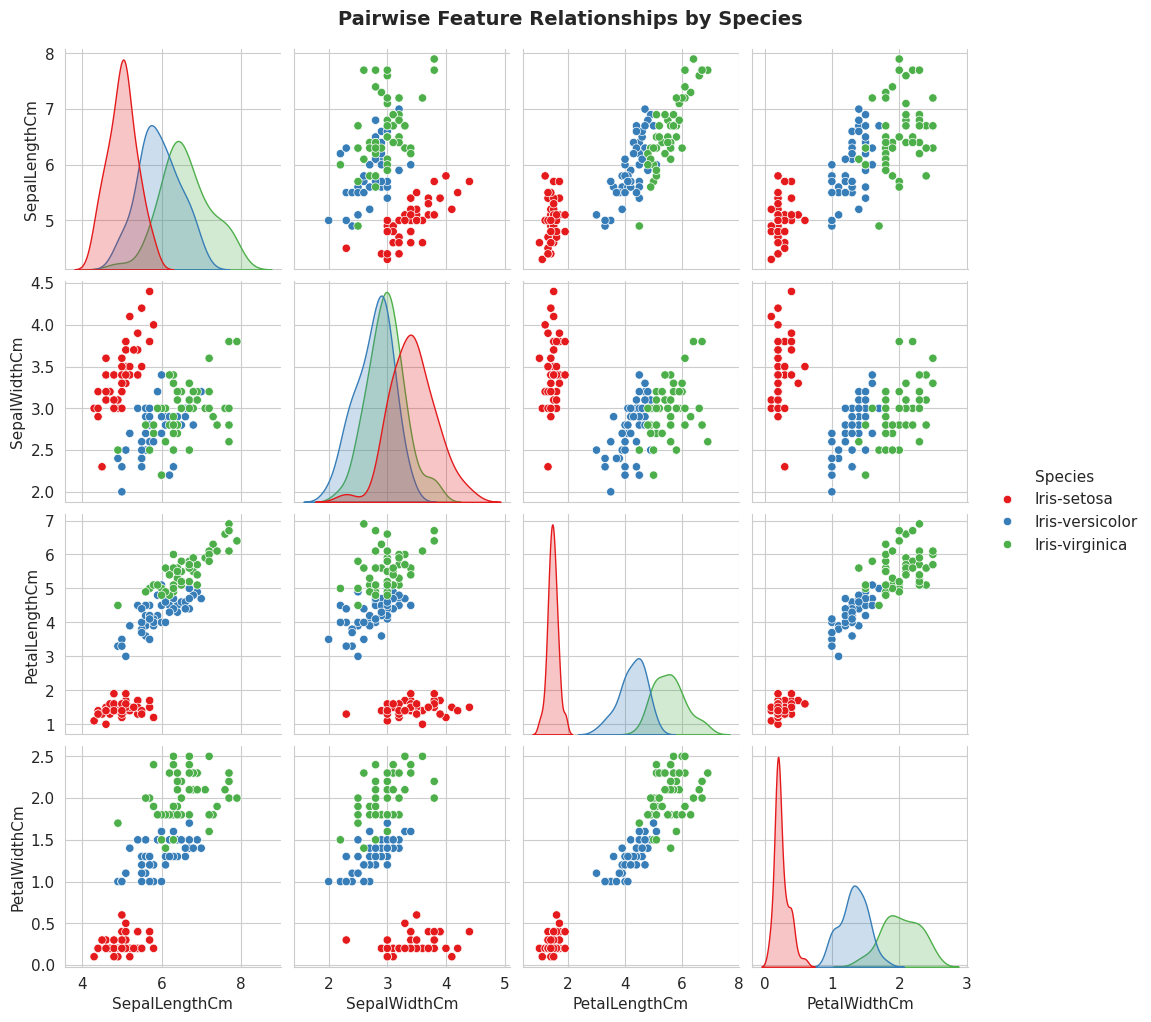

In [8]:
sns.pairplot(df_model, hue='Species', diag_kind='kde', palette='Set1', corner=False)
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('images/02_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


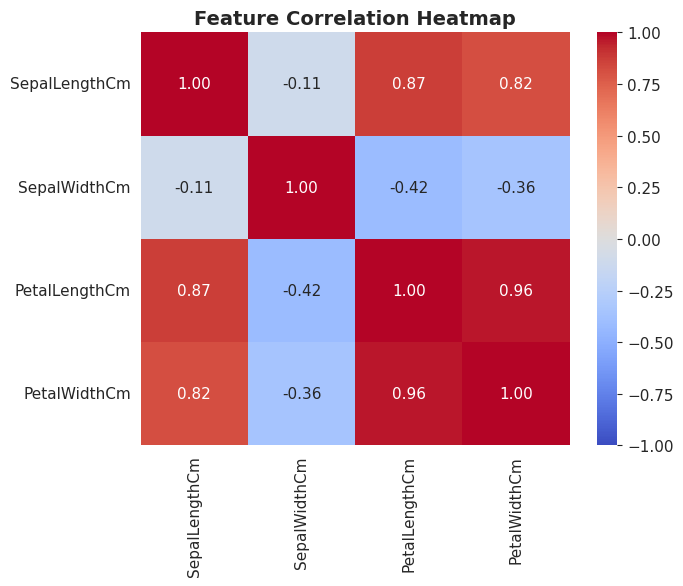

In [9]:
plt.figure(figsize=(7,6))
corr = df_model[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/03_correlation_heatmap.png', dpi=150)
plt.show()


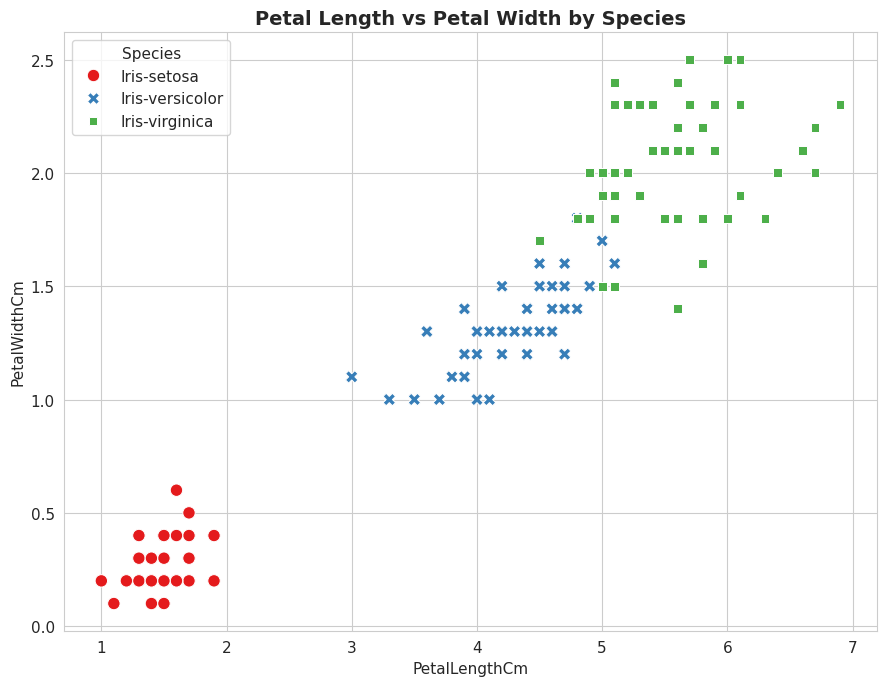

In [10]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df_model, x='PetalLengthCm', y='PetalWidthCm', hue='Species', style='Species', s=80, palette='Set1')
plt.title('Petal Length vs Petal Width by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/04_petal_scatter.png', dpi=150)
plt.show()


## 5. Preprocessing for Modeling

**Features:** `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`
**Target:** `Species` (3 classes)

The target is label-encoded to numeric form, and features are scaled for the
distance-based/linear models. We use a stratified train-test split to keep the
class balance identical in both sets.


In [11]:
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df_model[feature_cols]
y = df_model['Species']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Classes: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Train shape: (117, 4)  Test shape: (30, 4)


## 6. Model Training

We train and compare five classification models:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**


In [12]:
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'Decision Tree': Pipeline([('model', DecisionTreeClassifier(random_state=42, max_depth=4))]),
    'Random Forest': Pipeline([('model', RandomForestClassifier(random_state=42, n_estimators=200, max_depth=4))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', C=1.0))])
}

results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cv_scores = cross_val_score(pipe, X, y_encoded, cv=5, scoring='accuracy')

    results[name] = {'pipeline': pipe, 'accuracy': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}

    print(f"{name}")
    print(f"  Test Accuracy: {acc:.4f}  |  5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()


Logistic Regression
  Test Accuracy: 0.9333  |  5-Fold CV Accuracy: 0.9589 (+/- 0.0403)

KNN
  Test Accuracy: 0.9333  |  5-Fold CV Accuracy: 0.9591 (+/- 0.0259)

Decision Tree
  Test Accuracy: 0.9333  |  5-Fold CV Accuracy: 0.9453 (+/- 0.0470)



Random Forest
  Test Accuracy: 0.9667  |  5-Fold CV Accuracy: 0.9522 (+/- 0.0354)

SVM
  Test Accuracy: 0.9667  |  5-Fold CV Accuracy: 0.9660 (+/- 0.0218)



## 7. Model Comparison

In [13]:
comparison_df = pd.DataFrame({
    name: {'Test_Accuracy': r['accuracy'], 'CV_Accuracy_mean': r['cv_mean'], 'CV_Accuracy_std': r['cv_std']}
    for name, r in results.items()
}).T.sort_values('Test_Accuracy', ascending=False)

comparison_df


,Test_Accuracy,CV_Accuracy_mean,CV_Accuracy_std
SVM,0.966667,0.965977,0.021816
Random Forest,0.966667,0.952184,0.035350
Logistic Regression,0.933333,0.958851,0.040255
Decision Tree,0.933333,0.945287,0.046981
KNN,0.933333,0.959080,0.025933


/tmp/ipykernel_534/975676274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df['Test_Accuracy'], palette='viridis')


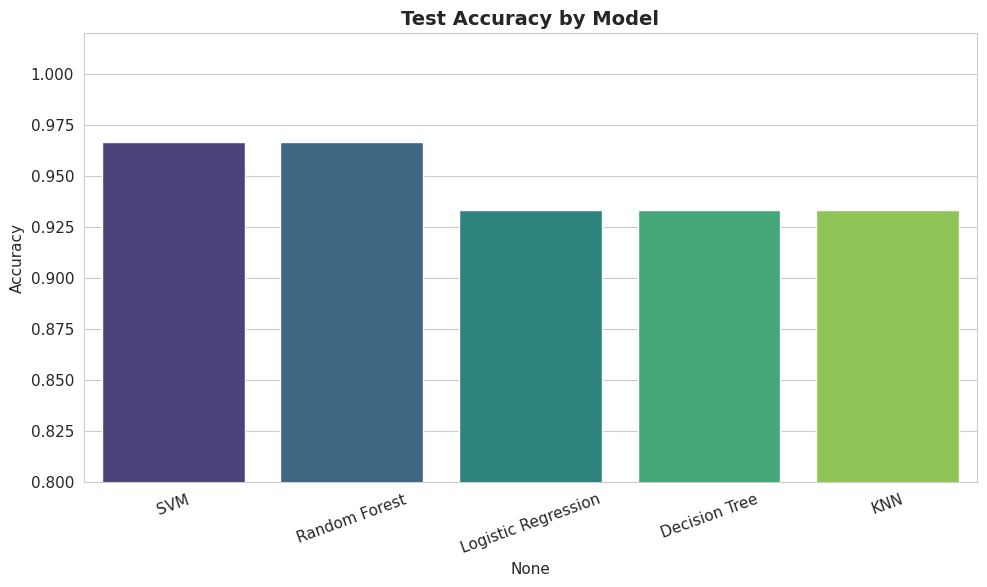

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x=comparison_df.index, y=comparison_df['Test_Accuracy'], palette='viridis')
plt.ylim(0.8, 1.02)
plt.title('Test Accuracy by Model', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('images/05_model_comparison.png', dpi=150)
plt.show()


In [15]:
best_model_name = comparison_df['Test_Accuracy'].idxmax()
best_pipeline = results[best_model_name]['pipeline']
print(f"Best performing model: {best_model_name} (Test Accuracy = {comparison_df.loc[best_model_name, 'Test_Accuracy']:.4f})")


Best performing model: SVM (Test Accuracy = 0.9667)


## 8. Detailed Evaluation of the Best Model

In [16]:
preds_best = best_pipeline.predict(X_test)

print(f"Classification Report — {best_model_name}\n")
print(classification_report(y_test, preds_best, target_names=le.classes_))


Classification Report — SVM

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



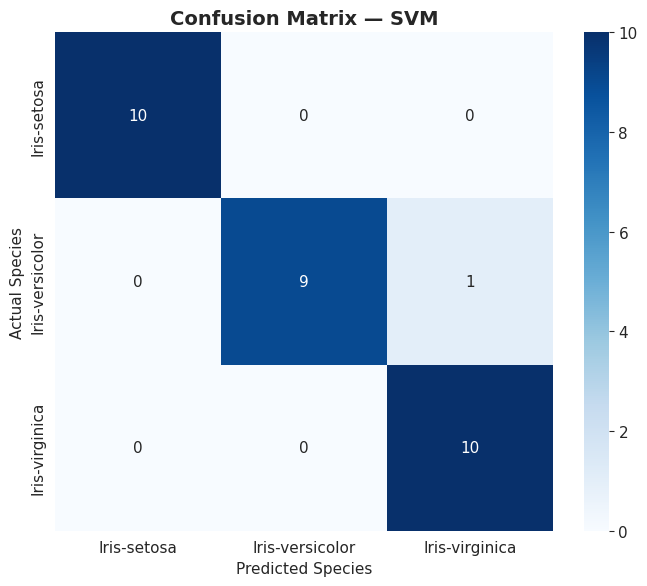

In [17]:
cm = confusion_matrix(y_test, preds_best)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.tight_layout()
plt.savefig('images/06_confusion_matrix.png', dpi=150)
plt.show()


## 9. Feature Importance (Random Forest)

Which measurements matter most for distinguishing species?


/tmp/ipykernel_534/104893322.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_series.values, y=importance_series.index, palette='mako')


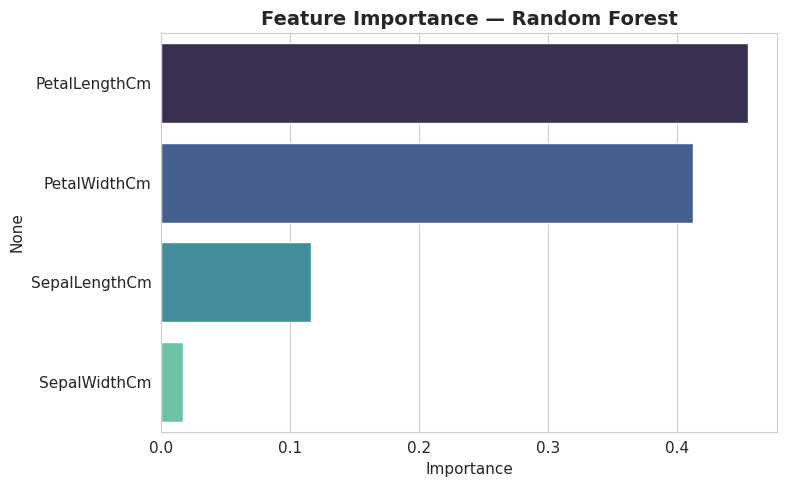

PetalLengthCm    0.454676
PetalWidthCm     0.412570
SepalLengthCm    0.116177
SepalWidthCm     0.016577
dtype: float64

In [18]:
rf_pipe = results['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
importance_series = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance_series.values, y=importance_series.index, palette='mako')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('images/07_feature_importance.png', dpi=150)
plt.show()

importance_series


## 10. Predicting the Species of a New Flower

In [19]:
new_flower = pd.DataFrame([{
    'SepalLengthCm': 5.8,
    'SepalWidthCm': 2.7,
    'PetalLengthCm': 4.1,
    'PetalWidthCm': 1.0
}])

predicted_class = best_pipeline.predict(new_flower)[0]
predicted_species = le.inverse_transform([predicted_class])[0]
print(f"Predicted Species: {predicted_species}")
new_flower


Predicted Species: Iris-versicolor


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.8,2.7,4.1,1.0


## 11. Key Insights

1. **Petal measurements (length & width) are far more discriminative than sepal
   measurements** for separating the three species — this is confirmed by both
   the pairplot/boxplots and the Random Forest feature importance ranking.
2. ***Iris-setosa* is perfectly linearly separable** from the other two species
   based on petal dimensions alone — it forms a tight, well-separated cluster.
3. ***Iris-versicolor* and *Iris-virginica* show some overlap**, particularly in
   sepal width, which is why a small number of misclassifications (if any) tend
   to occur between these two species rather than involving setosa.
4. **Multiple models achieve very high accuracy** (often at or near 100% on the
   test set) because the classes are well-separated and the dataset is small and
   clean — this is a classic, near-ideal classification problem.
5. **Simple models (Logistic Regression, KNN) perform comparably to more complex
   ensemble methods** here, showing that model complexity isn't always necessary
   when the underlying classes are well-separated.

## 12. Conclusion

This project trained and compared five classification algorithms to identify
Iris flower species from sepal and petal measurements. All models performed
well, with petal length and petal width emerging as the most important features
for classification. The best model achieved high accuracy on held-out test data,
demonstrating a solid, reproducible approach to a classic multi-class
classification problem.
